In [1]:
# =========================================================
# 0 - Environment Setup
# =========================================================

!pip install -q sentence-transformers scikit-learn

In [2]:
# =========================================================
# 1 - Imports
# =========================================================



import os
import json
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm

from sklearn.model_selection import train_test_split

from sentence_transformers import SentenceTransformer

from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [3]:
# =========================================================
# 2 - GPU Optimizations
# =========================================================

torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

print("TF32 acceleration enabled.")

TF32 acceleration enabled.


In [4]:
# =========================================================
# 3 - Seed Fixing
# =========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed fixed to:", SEED)

Seed fixed to: 42


In [5]:
# =========================================================
# 4 - Mount Google Drive
# =========================================================

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


**NOTE**  
ACTIVATION_LAYER can take any of the following values: 4, 8, 12, 16, 20, 24, 28, 31.   
Choose a value and re-run the whole thing from that point or it's better to disconnect and delete the run time and then run.   
I've done this for 7 times and got the results for each layer.  
I could have done it using a loop but the free trail has limitatins.

In [7]:
ACTIVATION_LAYER = 31

**NOTE**  
SELECTED can take either "wikitext" or "khanacademy".   
Choose a value and re-run the whole thing.

Say you have chosen ACTIVATION_LAYER as `4` and SELECTED as `wikitext`.  
Now, all the results will be saved under `Natural Language Autoencoder\wikitext\results\Layer_4` folder.

In [8]:
# SELECTED = "wikitext"
SELECTED = "khanacademy"

In [9]:
# =========================================================
# 5 - Define Paths
# =========================================================

PROJECT_DIR = "/content/drive/MyDrive/Natural Language Autoencoder"

DATA_DIR = os.path.join(PROJECT_DIR, "data", f"{SELECTED}")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results", f"{SELECTED}")
MODELS_DIR = os.path.join(PROJECT_DIR, "models", f"{SELECTED}")

os.makedirs(RESULTS_DIR, exist_ok = True)
os.makedirs(MODELS_DIR, exist_ok = True)

DATASET_JSON_PATH = os.path.join(DATA_DIR, "dataset.json")
ACTIVATIONS_PATH = os.path.join(DATA_DIR, f"layer_{ACTIVATION_LAYER}.pt")

print("\nDataset Path:", end = " ")
print(DATASET_JSON_PATH)

print("\nActivation Path:", end = " ")
print(ACTIVATIONS_PATH)


Dataset Path: /content/drive/MyDrive/Natural Language Autoencoder/data/khanacademy/dataset.json

Activation Path: /content/drive/MyDrive/Natural Language Autoencoder/data/khanacademy/layer_31.pt


In [10]:
# !apt-get install tree -q
# !tree "/content/drive/MyDrive/Natural Language Autoencoder"

In [11]:
MODEL_SAVE_DIR = os.path.join(MODELS_DIR, f"Layer_{ACTIVATION_LAYER}")
RESULTS_SAVE_DIR = os.path.join(RESULTS_DIR, f"Layer_{ACTIVATION_LAYER}")

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULTS_SAVE_DIR, exist_ok=True)

In [12]:
MODEL_SAVE_DIR

'/content/drive/MyDrive/Natural Language Autoencoder/models/khanacademy/Layer_31'

In [13]:
RESULTS_SAVE_DIR

'/content/drive/MyDrive/Natural Language Autoencoder/results/khanacademy/Layer_31'

In [14]:
# =========================================================
# 6 - Load Dataset
# =========================================================

with open(DATASET_JSON_PATH, "r") as f:

    dataset = json.load(f)

print("\nLoaded Samples:")
print(len(dataset))


Loaded Samples:
5000


In [15]:
# =========================================================
# 7 - Load Activations
# =========================================================

activations_tensor = torch.load(
    ACTIVATIONS_PATH
).float().cpu()

print("\nActivation Shape:")
print(activations_tensor.shape)

assert len(dataset) == activations_tensor.shape[0]

print("\nDataset and activations aligned.")


Activation Shape:
torch.Size([5000, 3072])

Dataset and activations aligned.


In [16]:
# =========================================================
# 8 - Extract Semantic Labels
# =========================================================

descriptions = [
    item["phi3_description"]
    for item in dataset
]

print("\nSample Descriptions:")
print(descriptions[:5])


Sample Descriptions:
['Economic cost curves analysis', 'Unit price comparison in grocery shopping', 'definite integral absolute value function', 'Magnetic field interaction between parallel current-carrying wires', 'Calculus Product Rule Application in Sales Analysis']


In [17]:
# =========================================================
# 9 - MiniLM Embedding Model
# =========================================================

EMBEDDING_MODEL_NAME = (
    "sentence-transformers/all-MiniLM-L6-v2"
)

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print("\nMiniLM loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


MiniLM loaded.


In [18]:
# =========================================================
# 10 - Generate Semantic Embeddings
# =========================================================

description_embeddings = embedding_model.encode(
    descriptions,
    batch_size=32,
    show_progress_bar=True,
    convert_to_tensor=True
).cpu()

print("\nEmbedding Shape:")
print(description_embeddings.shape)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Embedding Shape:
torch.Size([5000, 384])


In [19]:
# =========================================================
# 11 - Train/Test Split
# =========================================================

indices = np.arange(len(dataset))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

print("\nTrain Samples:", len(train_idx))
print("Test Samples:", len(test_idx))

X_train = activations_tensor[train_idx]
X_test = activations_tensor[test_idx]

Z_train = description_embeddings[train_idx]
Z_test = description_embeddings[test_idx]

print("\nX_train Shape:")
print(X_train.shape)

print("\nZ_train Shape:")
print(Z_train.shape)


Train Samples: 4500
Test Samples: 500

X_train Shape:
torch.Size([4500, 3072])

Z_train Shape:
torch.Size([4500, 384])


In [20]:
# =========================================================
# 12 - Dataset Class
# =========================================================

class NLADataset(Dataset):

    def __init__(
        self,
        activations,
        embeddings
    ):

        self.activations = activations
        self.embeddings = embeddings

    def __len__(self):

        return len(self.activations)

    def __getitem__(self, idx):

        return {
            "activation":
                self.activations[idx],

            "embedding":
                self.embeddings[idx]
        }

In [21]:
# =========================================================
# 13 - Create Datasets
# =========================================================

train_dataset = NLADataset(
    X_train,
    Z_train
)

test_dataset = NLADataset(
    X_test,
    Z_test
)

print("\nTrain Dataset Size:")
print(len(train_dataset))

print("\nTest Dataset Size:")
print(len(test_dataset))


Train Dataset Size:
4500

Test Dataset Size:
500


In [22]:
# =========================================================
# 14 - Create DataLoaders
# =========================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

print("\nDataLoaders ready.")


DataLoaders ready.


In [23]:
# =========================================================
# 15 - Device Setup
# =========================================================

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\nUsing Device:", end = " ")
print(device)


Using Device: cuda


In [24]:
# =========================================================
# 16 - Joint NLA Architecture
# =========================================================

class ActivationVerbalizer(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(3072, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(512, 128)
        )

    def forward(self, x):

        z = self.encoder(x)

        return z

class SemanticProjectionHead(nn.Module):

    def __init__(self):

        super().__init__()

        self.projector = nn.Sequential(

            nn.Linear(128, 256),
            nn.GELU(),

            nn.Linear(256, 384)
        )

    def forward(self, z):

        return self.projector(z)

class ActivationReconstructor(nn.Module):

    def __init__(self):

        super().__init__()

        self.decoder = nn.Sequential(

            nn.Linear(128, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(512, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(1024, 3072)
        )

    def forward(self, z):

        x_hat = self.decoder(z)

        return x_hat

class JointNLA(nn.Module):

    def __init__(self):

        super().__init__()

        self.av = ActivationVerbalizer()

        self.semantic_head = (
            SemanticProjectionHead()
        )

        self.ar = ActivationReconstructor()

    def forward(self, x):

        z = self.av(x)

        semantic_pred = self.semantic_head(z)

        x_hat = self.ar(z)

        return {
            "latent": z,
            "semantic_pred": semantic_pred,
            "reconstruction": x_hat
        }

In [25]:
# =========================================================
# 17 - Initialize Model
# =========================================================

model = JointNLA().to(device)

print("\nModel Initialized.")


Model Initialized.


In [26]:
# =========================================================
# 18 - Loss Functions & Optimizer
# =========================================================

mse_loss_fn = nn.MSELoss()

cosine_loss_fn = nn.CosineEmbeddingLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

LAMBDA_SEMANTIC = 1.0
LAMBDA_RECONSTRUCTION = 1.0

In [27]:
# =========================================================
# 19 - Training Function
# =========================================================

def train_epoch(model, loader):

    model.train()

    total_loss = 0

    total_semantic_loss = 0
    total_reconstruction_loss = 0

    for batch in loader:

        activations = batch[
            "activation"
        ].to(device, non_blocking = True)

        embeddings = batch[
            "embedding"
        ].to(device, non_blocking = True)

        optimizer.zero_grad()

        outputs = model(activations)

        semantic_pred = outputs[
            "semantic_pred"
        ]

        reconstruction = outputs[
            "reconstruction"
        ]

        # Semantic Loss

        semantic_mse = mse_loss_fn(
            semantic_pred,
            embeddings
        )

        target = torch.ones(
            activations.size(0)
        ).to(device)

        semantic_cosine = cosine_loss_fn(
            semantic_pred,
            embeddings,
            target
        )

        semantic_loss = (
            semantic_mse
            +
            semantic_cosine
        )

        # Reconstruction Loss

        reconstruction_loss = mse_loss_fn(
            reconstruction,
            activations
        )

        # Total Loss

        loss = (
            LAMBDA_SEMANTIC
            * semantic_loss
            +
            LAMBDA_RECONSTRUCTION
            * reconstruction_loss
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        total_semantic_loss += (
            semantic_loss.item()
        )

        total_reconstruction_loss += (
            reconstruction_loss.item()
        )

    avg_total_loss = (
        total_loss / len(loader)
    )

    avg_semantic_loss = (
        total_semantic_loss / len(loader)
    )

    avg_reconstruction_loss = (
        total_reconstruction_loss / len(loader)
    )

    return (
        avg_total_loss,
        avg_semantic_loss,
        avg_reconstruction_loss
    )

In [28]:
# =========================================================
# 20 - Evaluation Function
# =========================================================

def evaluate_epoch(model, loader):

    model.eval()

    total_loss = 0

    total_semantic_loss = 0
    total_reconstruction_loss = 0

    with torch.no_grad():

        for batch in loader:

            activations = batch[
                "activation"
            ].to(device, non_blocking = True)

            embeddings = batch[
                "embedding"
            ].to(device, non_blocking = True)

            outputs = model(
                activations
            )

            semantic_pred = outputs[
                "semantic_pred"
            ]

            reconstruction = outputs[
                "reconstruction"
            ]

            semantic_mse = mse_loss_fn(
                semantic_pred,
                embeddings
            )

            target = torch.ones(
                activations.size(0)
            ).to(device)

            semantic_cosine = cosine_loss_fn(
                semantic_pred,
                embeddings,
                target
            )

            semantic_loss = (
                semantic_mse
                +
                semantic_cosine
            )

            reconstruction_loss = mse_loss_fn(
                reconstruction,
                activations
            )

            loss = (
                LAMBDA_SEMANTIC
                * semantic_loss
                +
                LAMBDA_RECONSTRUCTION
                * reconstruction_loss
            )

            total_loss += loss.item()

            total_semantic_loss += (
                semantic_loss.item()
            )

            total_reconstruction_loss += (
                reconstruction_loss.item()
            )

    avg_total_loss = (
        total_loss / len(loader)
    )

    avg_semantic_loss = (
        total_semantic_loss / len(loader)
    )

    avg_reconstruction_loss = (
        total_reconstruction_loss / len(loader)
    )

    return (
        avg_total_loss,
        avg_semantic_loss,
        avg_reconstruction_loss
    )

In [29]:
# =========================================================
# 21 - Training Loop
# =========================================================

EPOCHS = 25

best_test_loss = float("inf")

for epoch in range(EPOCHS):

    (
        train_total,
        train_semantic,
        train_reconstruction
    ) = train_epoch(
        model,
        train_loader
    )

    (
        test_total,
        test_semantic,
        test_reconstruction
    ) = evaluate_epoch(
        model,
        test_loader
    )

    print("\n" + "=" * 60)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(
        f"Train Total Loss: "
        f"{train_total:.4f}"
    )

    print(
        f"Test Total Loss: "
        f"{test_total:.4f}"
    )

    print(
        f"Train Semantic Loss: "
        f"{train_semantic:.4f}"
    )

    print(
        f"Test Semantic Loss: "
        f"{test_semantic:.4f}"
    )

    print(
        f"Train Reconstruction Loss: "
        f"{train_reconstruction:.4f}"
    )

    print(
        f"Test Reconstruction Loss: "
        f"{test_reconstruction:.4f}"
    )

    # Save Best Model

    if test_total < best_test_loss:

        best_test_loss = test_total
        torch.save(model.state_dict(), os.path.join(MODEL_SAVE_DIR, "best_joint_nla.pt"))

        print("\nBest model saved.")


Epoch 1/25
Train Total Loss: 110.1825
Test Total Loss: 79.0337
Train Semantic Loss: 0.7272
Test Semantic Loss: 0.6753
Train Reconstruction Loss: 109.4553
Test Reconstruction Loss: 78.3584

Best model saved.

Epoch 2/25
Train Total Loss: 54.9807
Test Total Loss: 35.6797
Train Semantic Loss: 0.6091
Test Semantic Loss: 0.5721
Train Reconstruction Loss: 54.3716
Test Reconstruction Loss: 35.1076

Best model saved.

Epoch 3/25
Train Total Loss: 25.9686
Test Total Loss: 19.5031
Train Semantic Loss: 0.5373
Test Semantic Loss: 0.5416
Train Reconstruction Loss: 25.4313
Test Reconstruction Loss: 18.9615

Best model saved.

Epoch 4/25
Train Total Loss: 17.2461
Test Total Loss: 15.3362
Train Semantic Loss: 0.5284
Test Semantic Loss: 0.5191
Train Reconstruction Loss: 16.7177
Test Reconstruction Loss: 14.8171

Best model saved.

Epoch 5/25
Train Total Loss: 15.1307
Test Total Loss: 14.2715
Train Semantic Loss: 0.4974
Test Semantic Loss: 0.5039
Train Reconstruction Loss: 14.6333
Test Reconstruction L

In [30]:
# =========================================================
# 22 - Load Best Model
# =========================================================

model.load_state_dict(
    torch.load(
        os.path.join(
            MODEL_SAVE_DIR,
            "best_joint_nla.pt"
        )
    )
)

model.eval()

print("\nBest model loaded.")


Best model loaded.


In [31]:
# =========================================================
# 23 - Closed Loop Evaluation
# =========================================================

reconstructed_activations = []

latent_vectors = []

semantic_predictions = []

with torch.no_grad():

    for batch in test_loader:

        activations = batch[
            "activation"
        ].to(device)

        outputs = model(
            activations
        )

        reconstructed_activations.append(
            outputs["reconstruction"].cpu()
        )

        latent_vectors.append(
            outputs["latent"].cpu()
        )

        semantic_predictions.append(
            outputs["semantic_pred"].cpu()
        )

reconstructed_activations = torch.cat(
    reconstructed_activations,
    dim=0
)

latent_vectors = torch.cat(
    latent_vectors,
    dim=0
)

semantic_predictions = torch.cat(
    semantic_predictions,
    dim=0
)

In [32]:
# =========================================================
# 24 - FVE Computation
# =========================================================

def compute_fve(
    original,
    reconstructed
):

    original_mean = original.mean(
        dim=0
    )

    numerator = (
        (original - reconstructed) ** 2
    ).sum(dim=1)

    denominator = (
        (original - original_mean) ** 2
    ).sum(dim=1)

    fve = 1 - (
        numerator / denominator
    )

    return fve

fve_scores = compute_fve(
    X_test,
    reconstructed_activations
)

mean_fve = fve_scores.mean().item()

print("\nMean FVE:", end = " ")
print(round(mean_fve, 4))


Mean FVE: 0.5175


In [33]:
# =========================================================
# 25 - Cosine Similarity
# =========================================================

cosine_similarities = (
    F.cosine_similarity(
        X_test,
        reconstructed_activations,
        dim=1
    )
)

mean_cosine = (
    cosine_similarities.mean().item()
)

print("\nMean Cosine Similarity:")
print(round(mean_cosine, 4))


Mean Cosine Similarity:
0.9725


In [34]:
# =========================================================
# 26 - Latent Analysis
# =========================================================

latent_abs_mean = (
    latent_vectors.abs().mean(dim=0)
)

ACTIVE_THRESHOLD = 0.05

active_dimensions = (
    latent_abs_mean > ACTIVE_THRESHOLD
).sum().item()

print("\nActive Latent Dimensions:")
print(active_dimensions)

print("\nLatent Mean:")
print(latent_vectors.mean().item())

print("\nLatent Std:")
print(latent_vectors.std().item())

print("\nLatent Max:")
print(latent_vectors.max().item())

print("\nLatent Min:")
print(latent_vectors.min().item())


Active Latent Dimensions:
128

Latent Mean:
-0.0016165714478120208

Latent Std:
0.7377408742904663

Latent Max:
3.3648276329040527

Latent Min:
-3.109668254852295


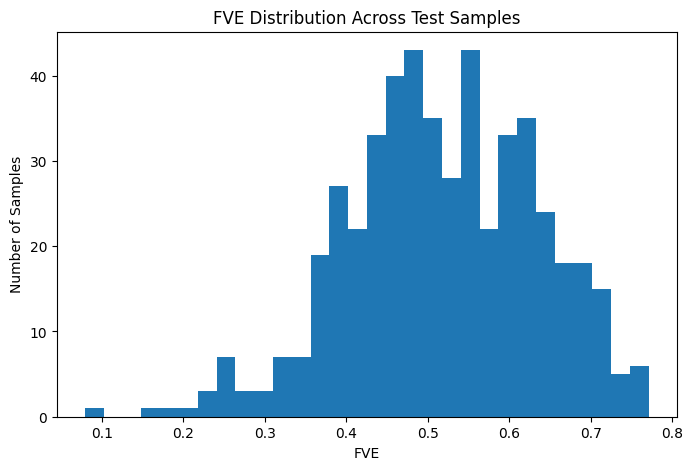

In [35]:
# =========================================================
# 27 - FVE Distribution Plot
# =========================================================

plt.figure(figsize=(8, 5))

plt.hist(
    fve_scores.numpy(),
    bins=30
)

plt.xlabel("FVE")
plt.ylabel("Number of Samples")

plt.title(
    "FVE Distribution Across Test Samples"
)

plt.savefig(
    os.path.join(
        RESULTS_SAVE_DIR,
        "fve_distribution.png"
    )
)

plt.show()

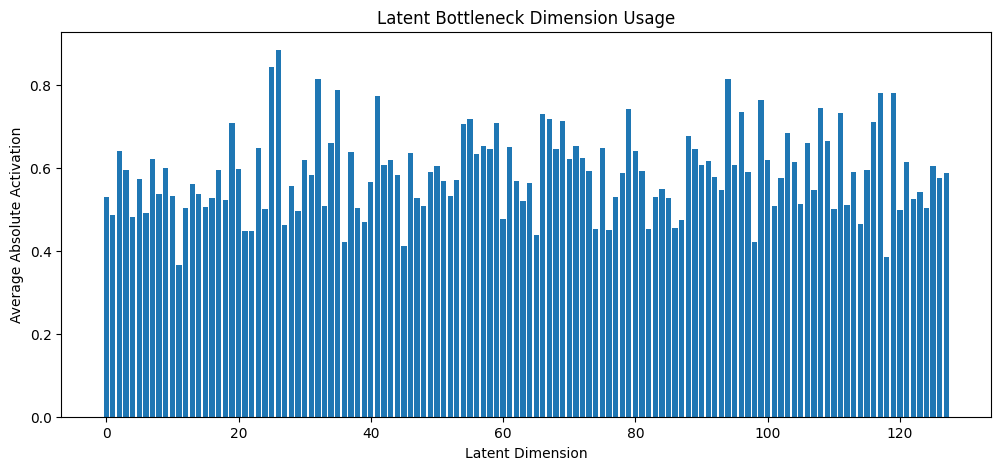

In [36]:
# =========================================================
# 28 - Latent Usage Plot
# =========================================================

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(128),
    latent_abs_mean.numpy()
)

plt.xlabel("Latent Dimension")
plt.ylabel("Average Absolute Activation")

plt.title(
    "Latent Bottleneck Dimension Usage"
)

plt.savefig(
    os.path.join(
        RESULTS_SAVE_DIR,
        "latent_usage.png"
    )
)

plt.show()

In [37]:
# =========================================================
# 29 - Best & Worst Reconstruction
# =========================================================

best_idx = torch.argmax(
    fve_scores
).item()

worst_idx = torch.argmin(
    fve_scores
).item()

print("\n" + "=" * 60)
print("BEST SAMPLE")
print("=" * 60)

print(
    "FVE:",
    round(
        fve_scores[best_idx].item(),
        4
    )
)

print("\nDescription:")

print(
    descriptions[
        test_idx[best_idx]
    ]
)

print("\n")

print("=" * 60)
print("WORST SAMPLE")
print("=" * 60)

print(
    "FVE:",
    round(
        fve_scores[worst_idx].item(),
        4
    )
)

print("\nDescription:")

print(
    descriptions[
        test_idx[worst_idx]
    ]
)


BEST SAMPLE
FVE: 0.7709

Description:
Linear Equations System Solving


WORST SAMPLE
FVE: 0.0793

Description:
Even and Odd Functions: Common Errors in Graphing, Tables, and


In [38]:
# =========================================================
# 30 - Save Final Results
# =========================================================

results = {

    "mean_fve":
        round(mean_fve, 4),

    "mean_cosine_similarity":
        round(mean_cosine, 4),

    "active_latent_dimensions":
        active_dimensions,

    "latent_mean":
        round(
            latent_vectors.mean().item(),
            4
        ),

    "latent_std":
        round(
            latent_vectors.std().item(),
            4
        ),

    "latent_max":
        round(
            latent_vectors.max().item(),
            4
        ),

    "latent_min":
        round(
            latent_vectors.min().item(),
            4
        )
}

torch.save(
    fve_scores,
    os.path.join(
        RESULTS_SAVE_DIR,
        "fve_scores.pt"
    )
)

results_path = os.path.join(
    RESULTS_SAVE_DIR,
    "joint_nla_results.json"
)

with open(results_path, "w") as f:

    json.dump(results, f, indent=2)

print("\nResults saved at", end = " ")

print(results_path)



Results saved at /content/drive/MyDrive/Natural Language Autoencoder/results/khanacademy/Layer_31/joint_nla_results.json


In [39]:
# =========================================================
# 31 - Final Summary
# =========================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(
    f"\nMean FVE: "
    f"{round(mean_fve, 4)}"
)

print(
    f"\nMean Cosine Similarity: "
    f"{round(mean_cosine, 4)}"
)

print(
    f"\nActive Latent Dimensions: "
    f"{active_dimensions}"
)

print("\nPipeline completed successfully.")





FINAL SUMMARY

Mean FVE: 0.5175

Mean Cosine Similarity: 0.9725

Active Latent Dimensions: 128

Pipeline completed successfully.
